# 01 bis - Exploration avec Polars

Objectif : refaire l'EDA du dataset IEEE-CIS Fraud Detection avec **Polars** pour accelerer le chargement, les aggregations et le feature engineering.

Ce notebook garde une logique pedagogique :
- Polars pour lire, filtrer, joindre et aggreger les donnees ;
- conversion ponctuelle en pandas pour `seaborn`, `matplotlib` et `scikit-learn` ;
- split temporel strict pour eviter la fuite de donnees ;
- baseline logistique pour montrer le piege de l'accuracy.


## 0. Installation et imports

Si besoin, installe les dependances :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn
```

Polars est tres rapide pour l'EDA, mais `scikit-learn` et `seaborn` utilisent encore surtout pandas/numpy. On convertira donc seulement les petits tableaux necessaires.


In [1]:
from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"
TEST_TRANSACTION_PATH = DATA_DIR / "test_transaction.csv"
TEST_IDENTITY_PATH = DATA_DIR / "test_identity.csv"

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH, TEST_TRANSACTION_PATH, TEST_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(120)


polars.config.Config

## 1. Chargement avec Polars

On utilise `scan_csv` pour preparer un plan lazy, puis `collect()` pour materialiser les donnees. Pour ce notebook d'EDA, on materialise le train complet apres la jointure.

La jointure reste la meme que dans la version pandas : toutes les transactions sont conservees, les informations d'identite sont ajoutees quand elles existent.


In [2]:
start = time.time()

train_transaction_lf = pl.scan_csv(TRAIN_TRANSACTION_PATH)
train_identity_lf = pl.scan_csv(TRAIN_IDENTITY_PATH)

train = (
    train_transaction_lf
    .join(train_identity_lf, on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

print(f"train fusionne : {train.shape}")
print(f"Temps de chargement + jointure : {time.time() - start:.1f} secondes")
train.head()


train fusionne : (590540, 434)
Temps de chargement + jointure : 48.4 secondes


TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,…,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
i64,i64,i64,f64,str,i64,f64,f64,str,f64,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str
2987000,0,86400,68.5,"""W""",13926,null,150.0,"""discover""",142.0,"""credit""",315.0,87.0,19.0,null,null,null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,null,13.0,null,null,null,null,null,null,13.0,13.0,null,null,null,0.0,"""T""","""T""","""T""","""M2""","""F""","""T""",null,null,null,1.0,1.0,1.0,1.0,1.0,…,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987001,0,86401,29.0,"""W""",2755,404.0,150.0,"""mastercard""",102.0,"""credit""",325.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,null,null,null,0.0,null,null,null,null,0.0,null,null,null,"""M0""","""T""","""T""",null,null,null,null,null,null,null,null,…,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987002,0,86469,59.0,"""W""",4663,490.0,150.0,"""visa""",166.0,"""debit""",330.0,87.0,287.0,null,"""outlook.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,null,null,null,0.0,315.0,null,null,null,315.0,"""T""","""T""","""T""","""M0""","""F""","""F""","""F""","""F""","""F""",1.0,1.0,1.0,1.0,1.0,…,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987003,0,86499,50.0,"""W""",18132,567.0,150.0,"""mastercard""",117.0,"""debit""",476.0,87.0,null,null,"""yahoo.com""",null,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,null,null,null,null,84.0,null,null,null,null,111.0,null,null,null,"""M0""","""T""","""F""",null,null,null,null,null,null,null,null,…,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987004,0,86506,50.0,"""H""",4497,514.0,150.0,"""mastercard""",102.0,"""credit""",420.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.0,0.0,0.0,0.0

In [3]:
# Apercu du schema Polars : noms de colonnes et types inferes.
print(f"Nombre de colonnes : {len(train.columns)}")
print(train.schema)


Nombre de colonnes : 434
Schema({'TransactionID': Int64, 'isFraud': Int64, 'TransactionDT': Int64, 'TransactionAmt': Float64, 'ProductCD': String, 'card1': Int64, 'card2': Float64, 'card3': Float64, 'card4': String, 'card5': Float64, 'card6': String, 'addr1': Float64, 'addr2': Float64, 'dist1': Float64, 'dist2': Float64, 'P_emaildomain': String, 'R_emaildomain': String, 'C1': Float64, 'C2': Float64, 'C3': Float64, 'C4': Float64, 'C5': Float64, 'C6': Float64, 'C7': Float64, 'C8': Float64, 'C9': Float64, 'C10': Float64, 'C11': Float64, 'C12': Float64, 'C13': Float64, 'C14': Float64, 'D1': Float64, 'D2': Float64, 'D3': Float64, 'D4': Float64, 'D5': Float64, 'D6': Float64, 'D7': Float64, 'D8': Float64, 'D9': Float64, 'D10': Float64, 'D11': Float64, 'D12': Float64, 'D13': Float64, 'D14': Float64, 'D15': Float64, 'M1': String, 'M2': String, 'M3': String, 'M4': String, 'M5': String, 'M6': String, 'M7': String, 'M8': String, 'M9': String, 'V1': Float64, 'V2': Float64, 'V3': Float64, 'V4': Floa

## 2. Desequilibre de classes

Avant de modeliser, on mesure la proportion de fraude. Un modele qui predit toujours "legitime" peut avoir une accuracy tres elevee, mais une utilite metier nulle.


In [4]:
class_balance = (
    train
    .group_by("isFraud")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("rate"))
    .sort("isFraud")
)

display(class_balance.to_pandas())

fraud_rate = train.select(pl.col("isFraud").mean()).item()
majority_accuracy = 1 - fraud_rate
print(f"Taux de fraude : {fraud_rate:.4%}")
print(f"Accuracy d'un classifieur toujours legitime : {majority_accuracy:.4%}")


,isFraud,count,rate
0,0,569877,0.9650
1,1,20663,0.0350


Taux de fraude : 3.4990%
Accuracy d'un classifieur toujours legitime : 96.5010%


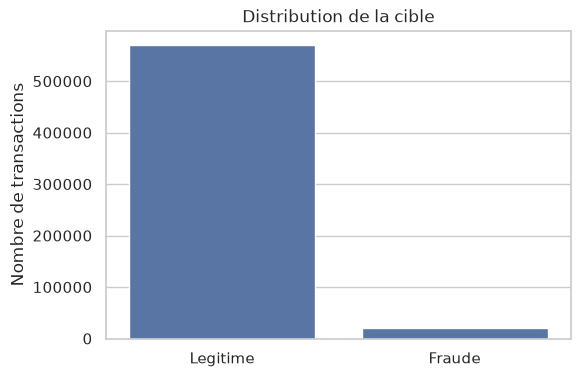

In [5]:
balance_pd = class_balance.with_columns(
    pl.when(pl.col("isFraud") == 1).then(pl.lit("Fraude")).otherwise(pl.lit("Legitime")).alias("classe")
).to_pandas()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=balance_pd, x="classe", y="count", ax=ax)
ax.set_title("Distribution de la cible")
ax.set_xlabel("")
ax.set_ylabel("Nombre de transactions")
plt.show()


## 3. Variables temporelles

`TransactionDT` est un temps relatif en secondes. On cree des colonnes temporelles utiles avec `with_columns`, ce qui est l'un des points forts de Polars.


In [6]:
SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

train.select(["TransactionDT", "hour_rel", "day_rel", "week_rel", "hour_of_day_rel"]).head()


TransactionDT,hour_rel,day_rel,week_rel,hour_of_day_rel
i64,i64,i64,i64,i64
86400,24,1,0,0
86401,24,1,0,0
86469,24,1,0,0
86499,24,1,0,0
86506,24,1,0,0


,day_rel,transactions,frauds,fraud_rate,amount_mean
0,1,5122,112,0.0219,144.9018
1,2,3730,123,0.0330,121.5550
2,3,3241,92,0.0284,107.5339
3,4,4036,115,0.0285,127.8417
4,5,3964,127,0.0320,137.0183


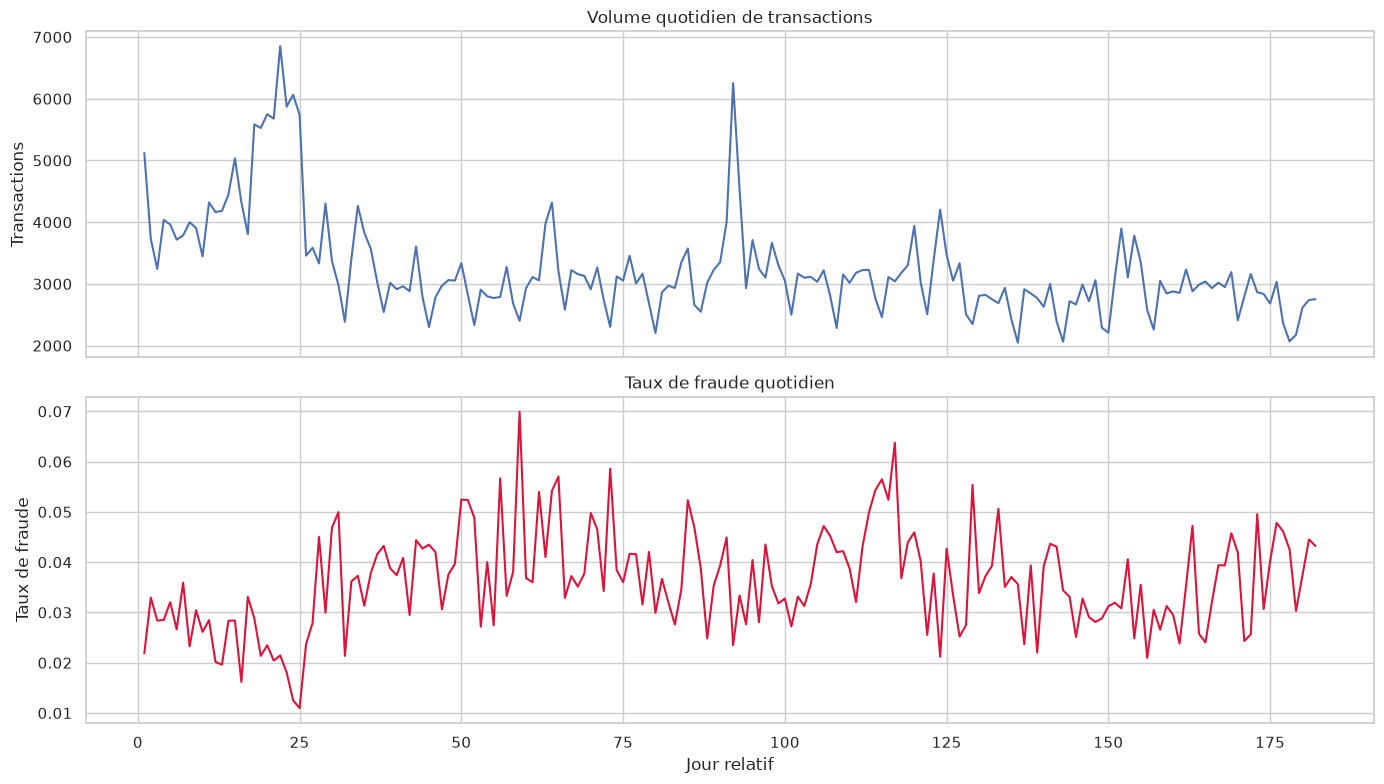

In [7]:
daily = (
    train
    .group_by("day_rel")
    .agg([
        pl.len().alias("transactions"),
        pl.col("isFraud").sum().alias("frauds"),
        pl.col("isFraud").mean().alias("fraud_rate"),
        pl.col("TransactionAmt").mean().alias("amount_mean"),
    ])
    .sort("day_rel")
)

display(daily.head().to_pandas())

daily_pd = daily.to_pandas()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=daily_pd, x="day_rel", y="transactions", ax=axes[0])
axes[0].set_title("Volume quotidien de transactions")
axes[0].set_ylabel("Transactions")

sns.lineplot(data=daily_pd, x="day_rel", y="fraud_rate", ax=axes[1], color="crimson")
axes[1].set_title("Taux de fraude quotidien")
axes[1].set_ylabel("Taux de fraude")
axes[1].set_xlabel("Jour relatif")
plt.tight_layout()
plt.show()


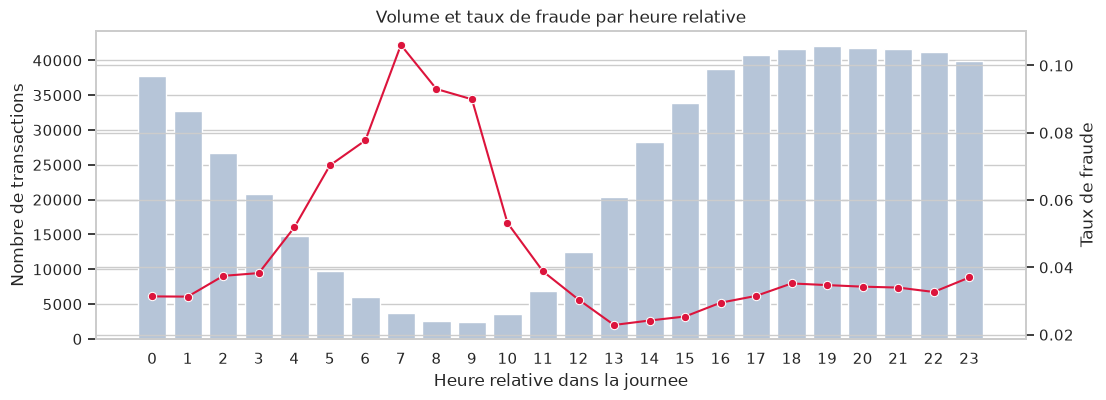

,hour_of_day_rel,transactions,fraud_rate
0,0,37795,0.0314
1,1,32797,0.0313
2,2,26732,0.0375
3,3,20802,0.0383
4,4,14839,0.0519
5,5,9701,0.0703
6,6,6007,0.0777
7,7,3704,0.1061
8,8,2591,0.0930
9,9,2479,0.0900


In [8]:
hourly = (
    train
    .group_by("hour_of_day_rel")
    .agg([
        pl.len().alias("transactions"),
        pl.col("isFraud").mean().alias("fraud_rate"),
    ])
    .sort("hour_of_day_rel")
)

hourly_pd = hourly.to_pandas()
fig, ax1 = plt.subplots(figsize=(12, 4))
sns.barplot(data=hourly_pd, x="hour_of_day_rel", y="transactions", color="lightsteelblue", ax=ax1)
ax1.set_ylabel("Nombre de transactions")
ax1.set_xlabel("Heure relative dans la journee")

ax2 = ax1.twinx()
sns.lineplot(data=hourly_pd, x="hour_of_day_rel", y="fraud_rate", color="crimson", marker="o", ax=ax2)
ax2.set_ylabel("Taux de fraude")
ax1.set_title("Volume et taux de fraude par heure relative")
plt.show()

display(hourly_pd)


## 4. Analyse des montants

Les montants sont tres asymetriques. On resume par classe, puis on visualise `log(1 + TransactionAmt)`.


In [11]:
amount_summary = (
    train
    .group_by("isFraud")
    .agg([
        pl.col("TransactionAmt").count().alias("count"),
        pl.col("TransactionAmt").mean().alias("mean"),
        pl.col("TransactionAmt").median().alias("median"),
        pl.col("TransactionAmt").std().alias("std"),
        pl.col("TransactionAmt").quantile(0.90).alias("p90"),
        pl.col("TransactionAmt").quantile(0.95).alias("p95"),
        pl.col("TransactionAmt").quantile(0.99).alias("p99"),
        pl.col("TransactionAmt").max().alias("max"),
    ])
    .sort("isFraud")
)

display(amount_summary.to_pandas())


,isFraud,count,mean,median,std,p90,p95,p99,max
0,0,569877,134.5117,68.5000,239.3951,267.0800,435.0000,"1,104.0000","31,937.3910"
1,1,20663,149.2448,75.0000,232.2122,335.0000,500.0000,994.0000,"5,191.0000"


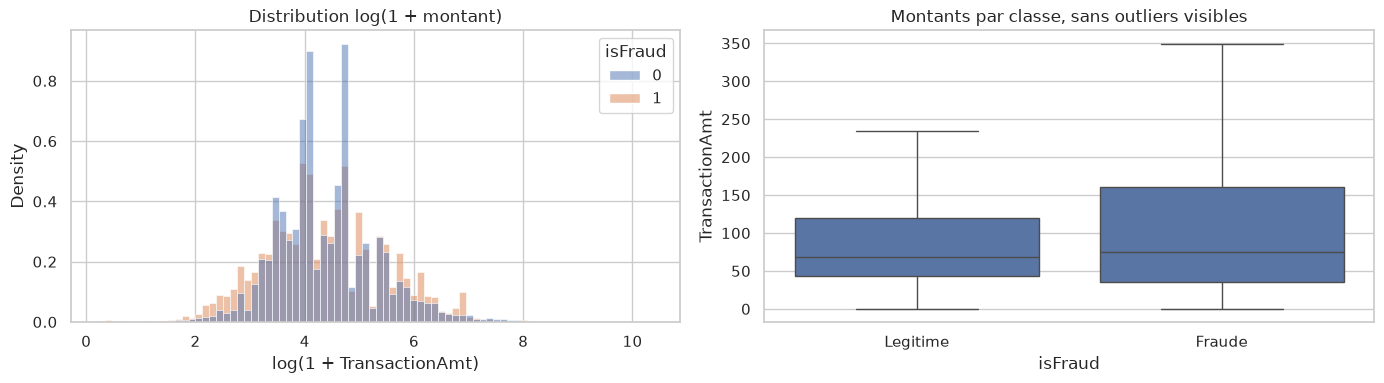

In [12]:
amount_pd = train.select(["TransactionAmt", "isFraud"]).with_columns(
    pl.col("TransactionAmt").log1p().alias("log_amount")
).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=amount_pd, x="log_amount", hue="isFraud", bins=80, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribution log(1 + montant)")
axes[0].set_xlabel("log(1 + TransactionAmt)")

sns.boxplot(data=amount_pd, x="isFraud", y="TransactionAmt", showfliers=False, ax=axes[1])
axes[1].set_title("Montants par classe, sans outliers visibles")
axes[1].set_xlabel("isFraud")
axes[1].set_ylabel("TransactionAmt")
axes[1].set_xticklabels(["Legitime", "Fraude"])
plt.tight_layout()
plt.show()


## 5. Categories metier

On calcule le taux de fraude par modalite pour quelques variables lisibles. On impose un volume minimum pour eviter les conclusions sur des categories trop rares.


In [14]:
def fraud_rate_by_category_pl(df, col, min_count=500, top_n=20):
    return (
        df
        .group_by(col)
        .agg([
            pl.len().alias("transactions"),
            pl.col("isFraud").mean().alias("fraud_rate"),
            pl.col("isFraud").sum().alias("frauds"),
        ])
        .filter(pl.col("transactions") >= min_count)
        .sort("fraud_rate", descending=True)
        .head(top_n)
    )

categorical_cols_to_check = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType"]

for col in categorical_cols_to_check:
    if col in train.columns:
        print(f"=== {col} ===")
        display(fraud_rate_by_category_pl(train, col).to_pandas())


=== ProductCD ===


,ProductCD,transactions,fraud_rate,frauds
0,C,68519,0.1169,8008
1,S,11628,0.0590,686
2,H,33024,0.0477,1574
3,R,37699,0.0378,1426
4,W,439670,0.0204,8969


=== card4 ===


,card4,transactions,fraud_rate,frauds
0,discover,6651,0.0773,514
1,visa,384767,0.0348,13373
2,mastercard,189217,0.0343,6496
3,american express,8328,0.0287,239
4,NaN,1577,0.0260,41


=== card6 ===


...

,P_emaildomain,transactions,fraud_rate,frauds
0,mail.com,559,0.1896,106
1,outlook.com,5096,0.0946,482
2,live.com.mx,749,0.0547,41
3,hotmail.com,45250,0.0530,2396
4,gmail.com,228355,0.0435,9943
5,icloud.com,6267,0.0314,197
6,comcast.net,7888,0.0312,246
7,charter.net,816,0.0306,25
8,NaN,94456,0.0295,2790
9,bellsouth.net,1909,0.0278,53


=== R_emaildomain ===


,R_emaildomain,transactions,fraud_rate,frauds
0,outlook.com,2507,0.1651,414
1,icloud.com,1398,0.1288,180
2,gmail.com,57147,0.1192,6811
3,hotmail.com,27509,0.0778,2140
4,live.com.mx,754,0.0584,44
5,yahoo.com,11842,0.0515,610
6,live.com,762,0.0499,38
7,aol.com,3701,0.0349,129
8,anonymous.com,20529,0.0291,598
9,NaN,453249,0.0208,9436


=== DeviceType ===


,DeviceType,transactions,fraud_rate,frauds
0,mobile,55645,0.1017,5657
1,desktop,85165,0.0652,5554
2,NaN,449730,0.0210,9452


## 6. Valeurs manquantes

Polars permet de compter les `null` rapidement avec `null_count()`. Les valeurs manquantes peuvent etre informatives dans un probleme de fraude.


,feature,missing_count,missing_rate
0,id_24,585793,0.9920
1,id_25,585408,0.9913
2,id_07,585385,0.9913
3,id_08,585385,0.9913
4,id_21,585381,0.9913
5,id_26,585377,0.9913
6,id_22,585371,0.9912
7,id_23,585371,0.9912
8,id_27,585371,0.9912
9,dist2,552913,0.9363


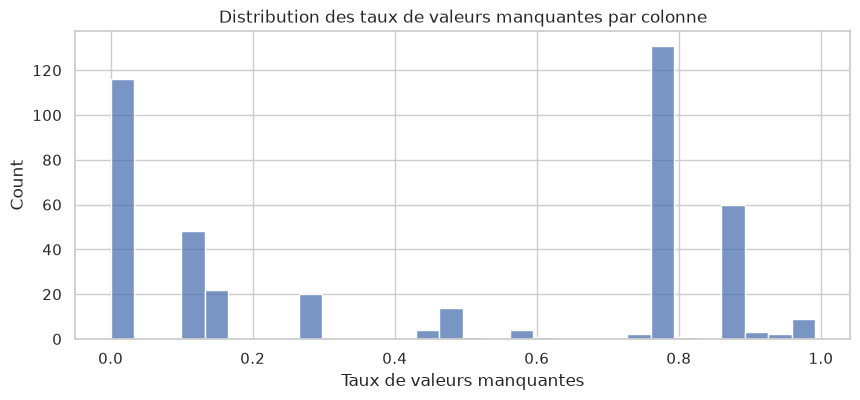

In [15]:
n_rows = train.height
missing = (
    train
    .null_count()
    .transpose(include_header=True, header_name="feature", column_names=["missing_count"])
    .with_columns((pl.col("missing_count") / n_rows).alias("missing_rate"))
    .sort("missing_rate", descending=True)
)

display(missing.head(30).to_pandas())

missing_pd = missing.to_pandas()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(missing_pd["missing_rate"], bins=30, ax=ax)
ax.set_title("Distribution des taux de valeurs manquantes par colonne")
ax.set_xlabel("Taux de valeurs manquantes")
plt.show()


## 7. Correlations simples avec la cible

Polars calcule les correlations colonne par colonne. On filtre les colonnes numeriques avec au moins 20 % de valeurs non manquantes pour eviter les signaux trop instables.


,feature,corr_with_isFraud,abs_corr
0,V257,0.3831,0.3831
1,V246,0.3669,0.3669
2,V244,0.3641,0.3641
3,V242,0.3606,0.3606
4,V201,0.3280,0.3280
5,V200,0.3188,0.3188
6,V189,0.3082,0.3082
7,V188,0.3036,0.3036
8,V258,0.2972,0.2972
9,V45,0.2818,0.2818


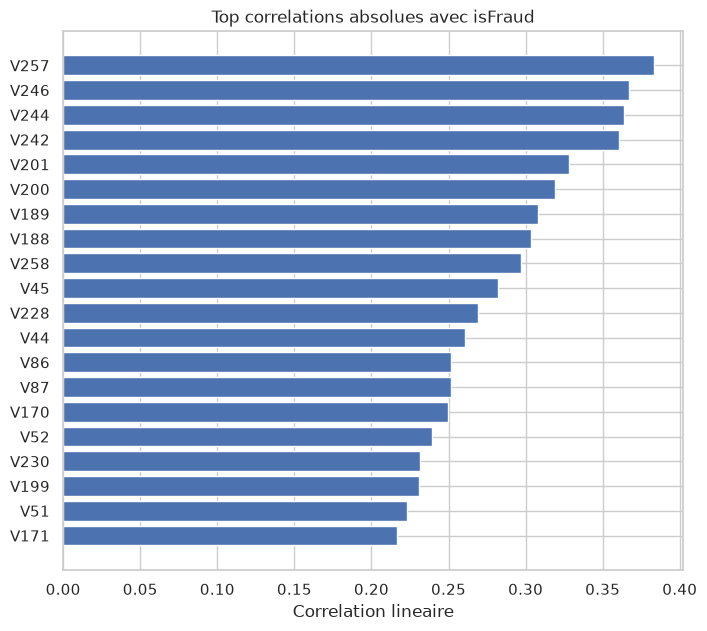

In [16]:
numeric_dtypes = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}

numeric_cols = [name for name, dtype in train.schema.items() if dtype in numeric_dtypes and name != "isFraud"]

nonnull_rates = train.select([
    (pl.col(col).is_not_null().mean()).alias(col) for col in numeric_cols
]).to_dicts()[0]
usable_numeric_cols = [col for col in numeric_cols if nonnull_rates[col] >= 0.20]

corr_rows = []
for col in usable_numeric_cols:
    value = train.select(pl.corr(col, "isFraud").alias("corr")).item()
    if value is not None and not np.isnan(value):
        corr_rows.append((col, value, abs(value)))

corr_df = pl.DataFrame(corr_rows, schema=["feature", "corr_with_isFraud", "abs_corr"], orient="row").sort("abs_corr", descending=True)
display(corr_df.head(25).to_pandas())

corr_pd = corr_df.head(20).sort("corr_with_isFraud").to_pandas()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(corr_pd["feature"], corr_pd["corr_with_isFraud"])
ax.set_title("Top correlations absolues avec isFraud")
ax.set_xlabel("Correlation lineaire")
plt.show()


## 8. Split temporel et baseline logistique

Le split est temporel : les premieres transactions entrainent le modele, les dernieres servent a l'evaluation. Pour `sklearn`, on convertit uniquement les colonnes selectionnees en pandas.


In [17]:
baseline_features = [
    "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2",
    "dist1", "dist2",
    "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_of_day_rel", "day_rel", "week_rel",
    "DeviceType",
]
baseline_features = [col for col in baseline_features if col in train.columns]

# On evite les doublons : day_rel est deja dans baseline_features.
model_columns = list(dict.fromkeys(baseline_features + ["isFraud", "day_rel"]))
model_pd = train.select(model_columns).to_pandas()
X = model_pd[baseline_features]
y = model_pd["isFraud"].astype(int)

split_idx = int(len(model_pd) * 0.8)
X_train, X_valid = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_valid = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {X_train.shape}, jours {model_pd['day_rel'].iloc[:split_idx].min()} -> {model_pd['day_rel'].iloc[:split_idx].max()}")
print(f"Valid : {X_valid.shape}, jours {model_pd['day_rel'].iloc[split_idx:].min()} -> {model_pd['day_rel'].iloc[split_idx:].max()}")
print(f"Taux fraude train : {y_train.mean():.4%}")
print(f"Taux fraude valid : {y_valid.mean():.4%}")


Train : (472432, 39), jours 1 -> 141
Valid : (118108, 39), jours 141 -> 182
Taux fraude train : 3.5135%
Taux fraude valid : 3.4409%


In [18]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=500, n_jobs=-1, random_state=RANDOM_STATE)),
    ]
)

start = time.time()
baseline_model.fit(X_train, y_train)
print(f"Temps d'entrainement baseline : {time.time() - start:.1f} secondes")


Temps d'entrainement baseline : 22.7 secondes


,baseline_logistic
accuracy,0.9662
recall_fraude,0.0529
f1,0.0972
AUPRC,0.2269


              precision    recall  f1-score   support

    legitime       0.97      1.00      0.98    114044
      fraude       0.59      0.05      0.10      4064

    accuracy                           0.97    118108
   macro avg       0.78      0.53      0.54    118108
weighted avg       0.95      0.97      0.95    118108



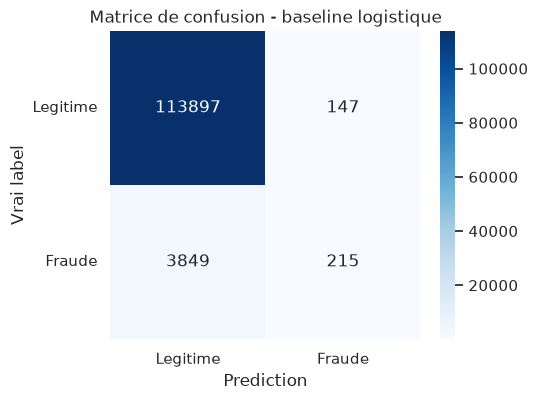

In [19]:
valid_scores = baseline_model.predict_proba(X_valid)[:, 1]
valid_pred = (valid_scores >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_valid, valid_pred),
    "recall_fraude": recall_score(y_valid, valid_pred, zero_division=0),
    "f1": f1_score(y_valid, valid_pred, zero_division=0),
    "AUPRC": average_precision_score(y_valid, valid_scores),
}

display(pd.Series(metrics).to_frame("baseline_logistic"))
print(classification_report(y_valid, valid_pred, target_names=["legitime", "fraude"], zero_division=0))

cm = confusion_matrix(y_valid, valid_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matrice de confusion - baseline logistique")
ax.set_xlabel("Prediction")
ax.set_ylabel("Vrai label")
ax.set_xticklabels(["Legitime", "Fraude"])
ax.set_yticklabels(["Legitime", "Fraude"], rotation=0)
plt.show()


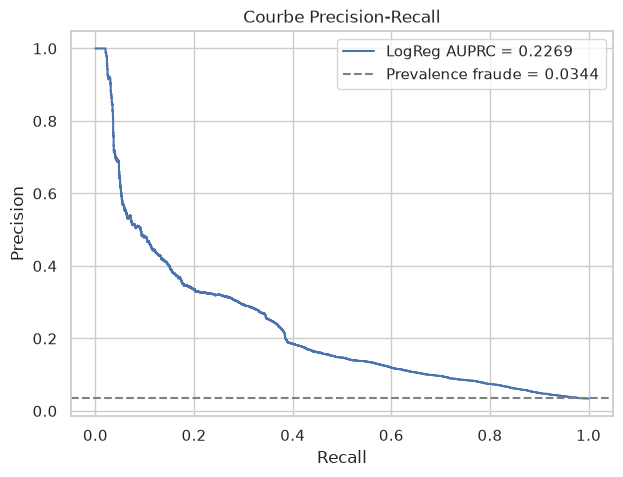

In [20]:
precision, recall, thresholds = precision_recall_curve(y_valid, valid_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label=f"LogReg AUPRC = {metrics['AUPRC']:.4f}")
ax.axhline(y_valid.mean(), color="gray", linestyle="--", label=f"Prevalence fraude = {y_valid.mean():.4f}")
ax.set_title("Courbe Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.show()


## 9. Demonstration de TimeSeriesSplit

Chaque fold de validation est posterieur a son fold d'entrainement. C'est indispensable pour simuler la production.


In [21]:
tscv = TimeSeriesSplit(n_splits=5)
fold_rows = []

days = model_pd["day_rel"].reset_index(drop=True)
target = model_pd["isFraud"].reset_index(drop=True)

for fold, (train_idx, valid_idx) in enumerate(tscv.split(model_pd), start=1):
    fold_rows.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "train_day_min": days.iloc[train_idx].min(),
        "train_day_max": days.iloc[train_idx].max(),
        "valid_day_min": days.iloc[valid_idx].min(),
        "valid_day_max": days.iloc[valid_idx].max(),
        "valid_fraud_rate": target.iloc[valid_idx].mean(),
    })

display(pd.DataFrame(fold_rows))


,fold,train_rows,valid_rows,train_day_min,train_day_max,valid_day_min,valid_day_max,valid_fraud_rate
0,1,98425,98423,1,22,22,51,0.0336
1,2,196848,98423,1,51,51,84,0.0412
2,3,295271,98423,1,84,84,114,0.0375
3,4,393694,98423,1,114,114,148,0.0375
4,5,492117,98423,1,148,148,182,0.0345


## 10. Feature engineering temporel avec Polars

IEEE-CIS n'a pas de vrai `customer_id`. Pour l'exploration, on construit un proxy client a partir de champs carte/adresse. Les features ci-dessous utilisent uniquement l'historique precedent grace a `shift(1).over(...)`.


In [23]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

train_fe = (
    train
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort("TransactionDT")
    .with_columns([
        pl.cum_count("TransactionID").over("customer_proxy").sub(1).alias("customer_tx_count_prev"),
        (
    pl.col("TransactionAmt").cum_sum().shift(1).over("customer_proxy")
    / pl.cum_count("TransactionID").sub(1).over("customer_proxy")
).alias("customer_amt_mean_prev"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        (pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev")).alias("amt_to_customer_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
)

new_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
]

display(train_fe.select(new_features + ["isFraud"]).head(10).to_pandas())

feature_summary = train_fe.group_by("isFraud").agg([
    pl.col(feature).mean().alias(f"{feature}_mean") for feature in new_features
] + [
    pl.col(feature).median().alias(f"{feature}_median") for feature in new_features
]).sort("isFraud")

display(feature_summary.to_pandas())


,customer_tx_count_prev,customer_amt_mean_prev,amt_to_customer_mean_prev,is_new_merchant_for_customer,isFraud
0,0,NaN,NaN,1,0
1,0,NaN,NaN,1,0
2,0,NaN,NaN,1,0
3,0,NaN,NaN,1,0
4,0,NaN,NaN,1,0
5,0,NaN,NaN,1,0
6,0,NaN,NaN,1,0
7,0,NaN,NaN,1,0
8,0,NaN,NaN,1,0
9,0,NaN,NaN,1,0


,isFraud,customer_tx_count_prev_mean,customer_amt_mean_prev_mean,amt_to_customer_mean_prev_mean,is_new_merchant_for_customer_mean,customer_tx_count_prev_median,customer_amt_mean_prev_median,amt_to_customer_mean_prev_median,is_new_merchant_for_customer_median
0,0,374.6107,128.4223,1.1429,0.1253,42.0000,109.8853,0.7127,0.0000
1,1,476.4548,118.0334,1.2750,0.1156,79.0000,88.4797,0.8560,0.0000


## 11. Synthese a completer

A remplir apres execution :

1. Taux de fraude observe : `...`.
2. Accuracy du classifieur majoritaire : `...`.
3. Variables temporelles interessantes : `...`.
4. Variables categorielles a risque : `...`.
5. Baseline logistique : accuracy `...`, recall fraude `...`, AUPRC `...`.
6. Gain pratique de Polars : chargement/agregations plus rapides, conversion necessaire pour plots et sklearn.

Conclusion attendue : Polars est un bon choix pour accelerer l'EDA et preparer les features, mais la modelisation sklearn reste plus simple apres conversion vers pandas/numpy.
